# Resume Screening and Job Category Classification Using Machine Learning

## Project Overview

Resume screening is an important task in recruitment because organizations receive a large
number of resumes for different job positions.

Manually reviewing every resume is time-consuming. Natural Language Processing (NLP) and
Machine Learning can be used to automatically analyze resume text and classify a resume
into an appropriate job category.

In this project, resume text is converted into numerical features using TF-IDF
(Term Frequency-Inverse Document Frequency), and multiple machine learning algorithms
are trained to classify resumes into different professional categories.

The project also includes model evaluation, hyperparameter tuning, error analysis,
model saving, and a prediction system for new resumes.

## Problem Statement

The objective of this project is to develop a machine learning system that can automatically
classify resumes into predefined job categories based on the textual information contained
in the resumes.

The system should:

1. Accept resume text as input.
2. Clean and preprocess the text.
3. Convert the text into numerical features using TF-IDF.
4. Train machine learning classification algorithms.
5. Compare the performance of multiple algorithms.
6. Select and tune an appropriate final model.
7. Evaluate the model on unseen test data.
8. Predict the category of a new resume.
9. Support extraction of text from resume files such as PDF and DOCX.

## Project Objectives

The major objectives of this project are:

- Perform exploratory data analysis on the resume dataset.
- Identify missing and duplicate records.
- Clean and normalize resume text.
- Prevent data leakage during model development.
- Convert resume text into TF-IDF features.
- Train multiple machine learning classification models.
- Compare their performance using appropriate evaluation metrics.
- Perform cross-validation.
- Tune the selected model using hyperparameter optimization.
- Evaluate the final model on unseen data.
- Analyze classification errors.
- Interpret important textual features.
- Save the trained model for future predictions.
- Build a system capable of predicting the category of new resumes.

In [12]:
# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import re

# Machine learning
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# Classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Pipeline and model persistence
from sklearn.pipeline import Pipeline
import joblib

# File handling
from pathlib import Path

# Display settings
import warnings
warnings.filterwarnings("ignore")

# Make notebook output easier to read
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [13]:
# ============================================================
# 2. LOAD THE DATASET
# ============================================================

# Define the dataset path.
# Change this path only if your CSV is stored somewhere else.
DATA_PATH = Path("UpdatedResumeDataSet.csv")

# Read the CSV file into a pandas DataFrame.
df = pd.read_csv(DATA_PATH)

# Display a confirmation message and dataset dimensions.
print(f"Dataset loaded successfully.")
print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")

# Display the first five records.
df.head()

Dataset loaded successfully.
Number of rows    : 962
Number of columns : 2


,Category,Resume
0,Data Science,"Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regress..."
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E UIT-RGPV\r\nData Scientist \r\n\r\nData Scientist - Matelabs\r\nSkill Details \r\nPython- Exprien...
2,Data Science,"Areas of Interest Deep Learning, Control System Design, Programming in-Python, Electric Machinery, Web Development, Analytics Technical Activities..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Tableau â¢ SAP HANA SQL â¢ SAP HANA PAL â¢ MS SQL â¢ SAP Lumira â¢ C# â¢ Linear Programming â¢ Dat...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridabad, Haryana\r\nData Science internship \r\n\r\n\r\nSkill Details \r\nData Structure- Exprience - Le..."


In [14]:
# ============================================================
# 3. BASIC DATASET INFORMATION
# ============================================================

# Display the column names.
print("Columns:")
print(df.columns.tolist())

# Display data types and non-null counts.
print("\nDataset Information:")
df.info()

# Display the statistical summary for object columns.
print("\nDataset Summary:")
display(df.describe(include="all"))

Columns:
['Category', 'Resume']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  962 non-null    object
 1   Resume    962 non-null    object
dtypes: object(2)
memory usage: 15.2+ KB

Dataset Summary:


,Category,Resume
count,962,962
unique,25,166
top,Java Developer,"Technical Skills Web Technologies: Angular JS, HTML5, CSS3, SASS, Bootstrap, Jquery, Javascript. Software: Brackets, Visual Studio, Photoshop, Vis..."
freq,84,18


In [15]:
# ============================================================
# 4. TARGET CATEGORY ANALYSIS
# ============================================================

# Count the number of unique job categories.
number_of_categories = df["Category"].nunique()

# Display all categories in alphabetical order.
categories = sorted(df["Category"].unique())

print(f"Number of unique job categories: {number_of_categories}")
print("\nJob Categories:")

for number, category in enumerate(categories, start=1):
    print(f"{number:02d}. {category}")

Number of unique job categories: 25

Job Categories:
01. Advocate
02. Arts
03. Automation Testing
04. Blockchain
05. Business Analyst
06. Civil Engineer
07. Data Science
08. Database
09. DevOps Engineer
10. DotNet Developer
11. ETL Developer
12. Electrical Engineering
13. HR
14. Hadoop
15. Health and fitness
16. Java Developer
17. Mechanical Engineer
18. Network Security Engineer
19. Operations Manager
20. PMO
21. Python Developer
22. SAP Developer
23. Sales
24. Testing
25. Web Designing


In [16]:
# ============================================================
# 5. DATA QUALITY CHECK
# ============================================================

# Count missing values in every column.
missing_values = df.isnull().sum()

print("Missing values:")
display(missing_values)

# Count completely duplicated rows.
duplicate_rows = df.duplicated().sum()

# Count duplicated resume text.
duplicate_resumes = df["Resume"].duplicated().sum()

# Count empty or whitespace-only resumes.
empty_resumes = df["Resume"].fillna("").str.strip().eq("").sum()

print(f"Completely duplicated rows : {duplicate_rows}")
print(f"Duplicated resume texts    : {duplicate_resumes}")
print(f"Empty resume texts         : {empty_resumes}")

Missing values:


Category    0
Resume      0
dtype: int64

Completely duplicated rows : 796
Duplicated resume texts    : 796
Empty resume texts         : 0


In [17]:
# ============================================================
# 6. RESUME LENGTH FEATURES
# ============================================================

# Calculate simple text-length features.
# These features are used for analysis only and are NOT used
# directly as model inputs.
df["character_count"] = df["Resume"].str.len()
df["word_count"] = df["Resume"].str.split().str.len()

# Display descriptive statistics.
display(
    df[["character_count", "word_count"]].describe()
)

,character_count,word_count
count,962.000000,962.000000
mean,3160.364865,450.497921
std,2886.528521,415.868459
min,142.000000,19.000000
25%,1217.250000,166.000000
50%,2355.000000,329.000000
75%,4073.750000,589.250000
max,14816.000000,2209.000000


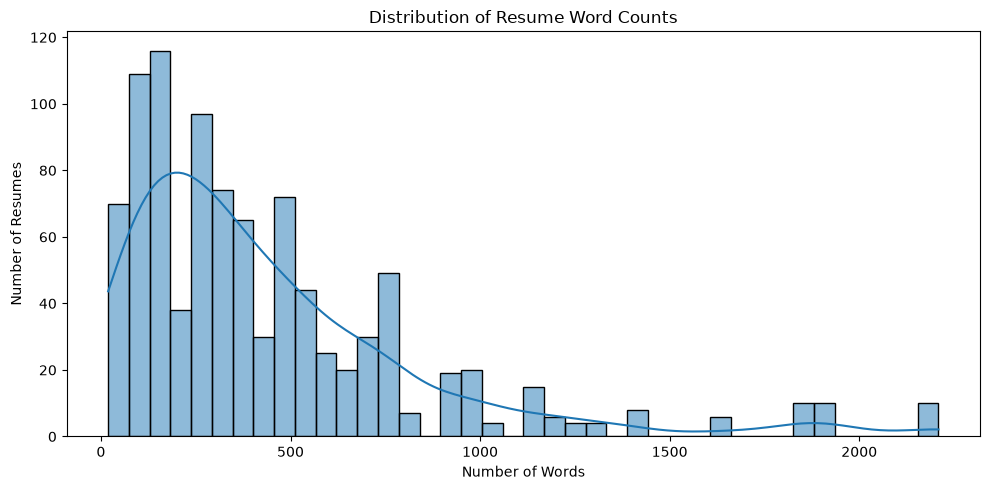

In [18]:
# ============================================================
# 7. RESUME LENGTH VISUALIZATION
# ============================================================

# Create a histogram of resume word counts.
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="word_count",
    bins=40,
    kde=True
)

plt.title("Distribution of Resume Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Number of Resumes")
plt.tight_layout()
plt.show()

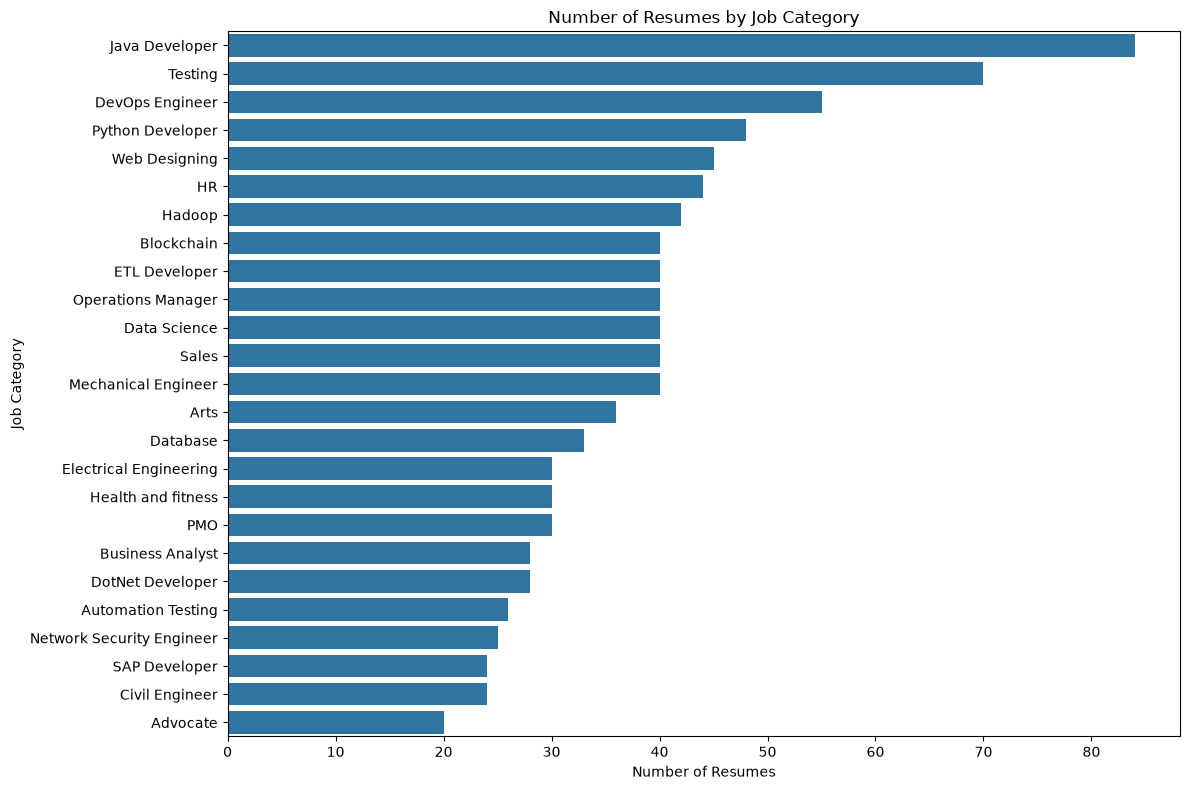

In [19]:
# ============================================================
# 8. JOB CATEGORY DISTRIBUTION
# ============================================================

# Count resumes belonging to each category.
category_counts = df["Category"].value_counts()

# Plot the distribution.
plt.figure(figsize=(12, 8))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title("Number of Resumes by Job Category")
plt.xlabel("Number of Resumes")
plt.ylabel("Job Category")
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# 9. ANALYZE DUPLICATE RESUMES
# ============================================================

# Count unique resume texts.
unique_resume_count = df["Resume"].nunique()

# Count total records.
total_resume_count = len(df)

# Calculate duplicate percentage.
duplicate_percentage = (
    (total_resume_count - unique_resume_count)
    / total_resume_count
) * 100

print(f"Total resume records : {total_resume_count}")
print(f"Unique resume texts  : {unique_resume_count}")
print(f"Duplicate records    : {total_resume_count - unique_resume_count}")
print(f"Duplicate percentage : {duplicate_percentage:.2f}%")

Total resume records : 962
Unique resume texts  : 166
Duplicate records    : 796
Duplicate percentage : 82.74%


In [21]:
# ============================================================
# 10. CREATE CLEAN MODELING DATA
# ============================================================

# Keep only the original modeling columns.
model_df = df[["Category", "Resume"]].copy()

# Remove rows with missing values.
model_df = model_df.dropna(subset=["Category", "Resume"])

# Remove empty resume texts.
model_df = model_df[
    model_df["Resume"].str.strip().ne("")
]

print(f"Original records : {len(df)}")
print(f"Clean records    : {len(model_df)}")
print(f"Unique resumes   : {model_df['Resume'].nunique()}")
print(f"Unique categories: {model_df['Category'].nunique()}")

Original records : 962
Clean records    : 962
Unique resumes   : 166
Unique categories: 25


In [22]:
# ============================================================
# 11. TEXT CLEANING FUNCTION
# ============================================================

def clean_resume_text(text):
    """
    Clean resume text while preserving useful professional keywords.

    Steps:
    1. Convert text to lowercase.
    2. Remove URLs.
    3. Remove email addresses.
    4. Remove non-alphanumeric symbols.
    5. Normalize multiple spaces.
    """

    # Convert the input to string and lowercase it.
    text = str(text).lower()

    # Remove URLs.
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove email addresses.
    text = re.sub(
        r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
        " ",
        text
    )

    # Keep letters, numbers and spaces.
    # Numbers can be useful in resumes because they may represent
    # technologies, versions, years of experience, etc.
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Replace multiple spaces with one space.
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [23]:
# ============================================================
# 12. APPLY TEXT CLEANING
# ============================================================

# Create the cleaned resume text column.
model_df["clean_resume"] = model_df["Resume"].apply(clean_resume_text)

# Display original and cleaned examples.
display(
    model_df[["Resume", "clean_resume"]].head(3)
)

,Resume,clean_resume
0,"Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regress...",skills programming languages python pandas numpy scipy scikit learn matplotlib sql java javascript jquery machine learning regression svm na ve ba...
1,Education Details \r\nMay 2013 to May 2017 B.E UIT-RGPV\r\nData Scientist \r\n\r\nData Scientist - Matelabs\r\nSkill Details \r\nPython- Exprien...,education details may 2013 to may 2017 b e uit rgpv data scientist data scientist matelabs skill details python exprience less than 1 year months ...
2,"Areas of Interest Deep Learning, Control System Design, Programming in-Python, Electric Machinery, Web Development, Analytics Technical Activities...",areas of interest deep learning control system design programming in python electric machinery web development analytics technical activities q hi...


In [24]:
# ============================================================
# 13. ENCODE THE TARGET VARIABLE
# ============================================================

# Create the label encoder.
label_encoder = LabelEncoder()

# Convert job category names into numerical labels.
y = label_encoder.fit_transform(model_df["Category"])

# Store cleaned resume text as the input feature.
X = model_df["clean_resume"]

# Display the mapping between numbers and categories.
label_mapping = pd.DataFrame({
    "Encoded_Label": range(len(label_encoder.classes_)),
    "Category": label_encoder.classes_
})

display(label_mapping)

,Encoded_Label,Category
0,0,Advocate
1,1,Arts
2,2,Automation Testing
3,3,Blockchain
4,4,Business Analyst
5,5,Civil Engineer
6,6,Data Science
7,7,Database
8,8,DevOps Engineer
9,9,DotNet Developer


In [25]:
# ============================================================
# 14. TRAIN / TEST SPLIT
# ============================================================

# Split the unique resume dataset into training and testing sets.
# Stratification ensures that the category distribution is
# approximately maintained in both subsets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"Training ratio   : {len(X_train) / len(X):.2%}")
print(f"Testing ratio    : {len(X_test) / len(X):.2%}")

Training samples : 769
Testing samples  : 193
Training ratio   : 79.94%
Testing ratio    : 20.06%


In [26]:
# ============================================================
# 15. TF-IDF FEATURE EXTRACTION
# ============================================================

# Create the TF-IDF vectorizer.
# Unigrams and bigrams allow the model to learn both individual
# words and useful two-word combinations.
tfidf = TfidfVectorizer(
    sublinear_tf=True,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    max_features=50000
)

# Learn vocabulary and TF-IDF weights only from training text.
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test text using the training vocabulary.
X_test_tfidf = tfidf.transform(X_test)

print(f"Training TF-IDF shape: {X_train_tfidf.shape}")
print(f"Testing TF-IDF shape : {X_test_tfidf.shape}")

Training TF-IDF shape: (769, 45569)
Testing TF-IDF shape : (193, 45569)


In [27]:
# ============================================================
# 16. TRAIN MULTIPLE MACHINE LEARNING MODELS
# ============================================================

# Define all candidate classifiers in one dictionary.
# This allows us to train and compare models using the same
# evaluation workflow.
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced"
    ),

    "Linear SVM": LinearSVC(
        class_weight="balanced"
    ),

    "Multinomial Naive Bayes": MultinomialNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    )
}

# Store trained models so that they can be reused later.
trained_models = {}

# Train every candidate model using the same TF-IDF features.
for model_name, model in models.items():

    print(f"Training {model_name}...")

    model.fit(X_train_tfidf, y_train)

    trained_models[model_name] = model

print("\nAll models trained successfully.")

Training Logistic Regression...
Training Linear SVM...
Training Multinomial Naive Bayes...
Training Random Forest...

All models trained successfully.


In [28]:
# ============================================================
# 17. MODEL COMPARISON
# ============================================================

# Create an empty list to collect evaluation results.
comparison_results = []

# Evaluate every trained model using the same untouched test set.
for model_name, model in trained_models.items():

    # Generate predictions.
    predictions = model.predict(X_test_tfidf)

    # Calculate standard classification metrics.
    comparison_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        )
    })

# Convert the results into a DataFrame.
comparison_df = pd.DataFrame(comparison_results)

# Sort models by F1 score.
comparison_df = comparison_df.sort_values(
    "F1 Score",
    ascending=False
).reset_index(drop=True)

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.994819,0.995682,0.994819,0.994931
1,Linear SVM,0.994819,0.995682,0.994819,0.994931
2,Random Forest,0.994819,0.995682,0.994819,0.994931
3,Multinomial Naive Bayes,0.948187,0.942021,0.948187,0.935455


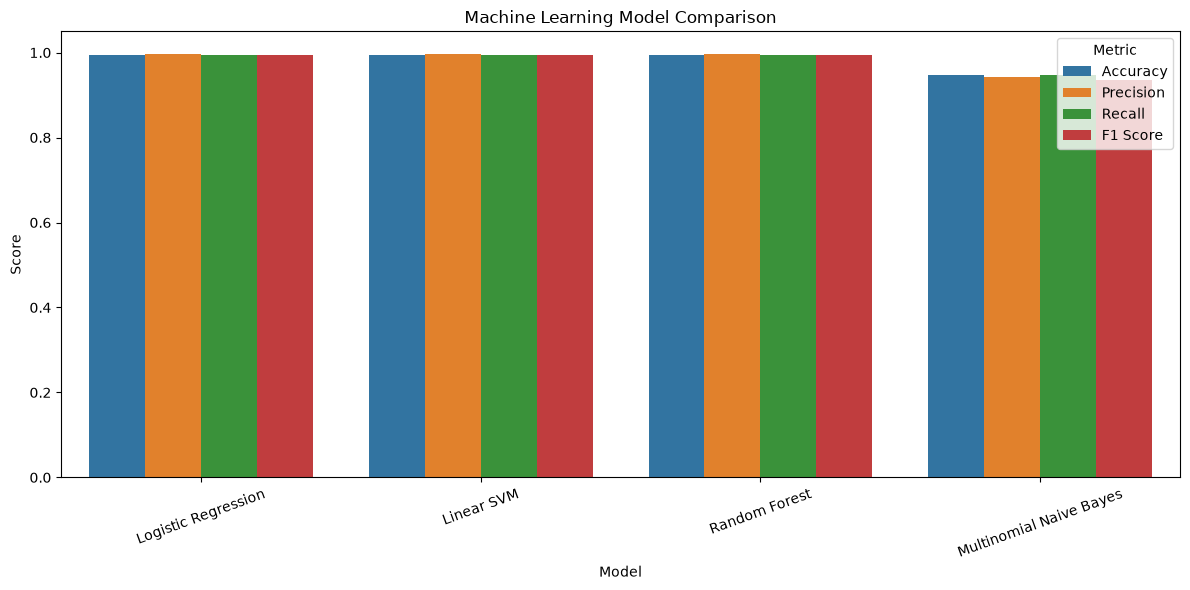

In [29]:
# ============================================================
# 18. MODEL PERFORMANCE VISUALIZATION
# ============================================================

# Convert the comparison table into a plotting format.
plot_df = comparison_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

# Plot the model comparison.
plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_df,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Machine Learning Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# 19. STRATIFIED CROSS-VALIDATION
# ============================================================

# Use 5-fold stratified cross-validation so that each fold
# maintains approximately the same class distribution.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

# Evaluate each already-defined model using only the training data.
for model_name, model in models.items():

    scores = cross_validate(
        model,
        X_train_tfidf,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision_weighted",
            "recall": "recall_weighted",
            "f1": "f1_weighted"
        },
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "Mean Accuracy": scores["test_accuracy"].mean(),
        "Mean Precision": scores["test_precision"].mean(),
        "Mean Recall": scores["test_recall"].mean(),
        "Mean F1": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    "Mean F1",
    ascending=False
).reset_index(drop=True)

display(cv_results_df)

,Model,Mean Accuracy,Mean Precision,Mean Recall,Mean F1,F1 Std
0,Linear SVM,0.994797,0.995627,0.994797,0.994817,0.002595
1,Random Forest,0.993490,0.994413,0.993490,0.993441,0.004191
2,Logistic Regression,0.993490,0.994370,0.993490,0.993427,0.004212
3,Multinomial Naive Bayes,0.938902,0.939762,0.938902,0.929847,0.020887


In [31]:
# ============================================================
# 20. IDENTIFY THE CANDIDATE MODEL
# ============================================================

# Select the model with the highest cross-validation F1 score.
candidate_model_name = cv_results_df.iloc[0]["Model"]

print("Candidate model for hyperparameter tuning:")
print(candidate_model_name)

Candidate model for hyperparameter tuning:
Linear SVM


In [32]:
# ============================================================
# 21. HYPERPARAMETER TUNING
# ============================================================

# Define the parameter combinations to test for Linear SVM.
svm_parameter_grid = {
    "C": [0.1, 0.5, 1, 2, 5, 10],
    "class_weight": [None, "balanced"]
}

# Create a fresh Linear SVM model.
svm_model = LinearSVC()

# GridSearchCV tests every parameter combination using
# stratified cross-validation.
grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=svm_parameter_grid,
    scoring="f1_weighted",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Fit the grid search ONLY on training features.
grid_search.fit(X_train_tfidf, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1:")
print(f"{grid_search.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters:
{'C': 0.1, 'class_weight': 'balanced'}

Best cross-validation F1:
0.9948


In [33]:
# ============================================================
# 22. FINAL MODEL
# ============================================================

# Store the best estimator discovered by GridSearchCV.
final_model = grid_search.best_estimator_

print("Final model:")
print(final_model)

Final model:
LinearSVC(C=0.1, class_weight='balanced')


In [34]:
# ============================================================
# 23. FINAL TEST PREDICTIONS
# ============================================================

# Generate predictions for the unseen test data.
final_predictions = final_model.predict(X_test_tfidf)

print("Predictions generated successfully.")

Predictions generated successfully.


In [35]:
# ============================================================
# 24. FINAL MODEL EVALUATION
# ============================================================

# Calculate final evaluation metrics.
final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions,
    average="weighted",
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_predictions,
    average="weighted",
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_predictions,
    average="weighted",
    zero_division=0
)

print("FINAL MODEL PERFORMANCE")
print("=" * 40)
print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")

FINAL MODEL PERFORMANCE
Accuracy  : 0.9948
Precision : 0.9957
Recall    : 0.9948
F1 Score  : 0.9949


In [36]:
# ============================================================
# 25. CLASSIFICATION REPORT
# ============================================================

# Convert numerical predictions back into category names.
actual_categories = label_encoder.inverse_transform(y_test)
predicted_categories = label_encoder.inverse_transform(
    final_predictions
)

# Generate a detailed classification report.
report = classification_report(
    y_test,
    final_predictions,
    target_names=label_encoder.classes_,
    zero_division=0
)

print(report)

                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       0.83      1.00      0.91         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       1.00      1.00      1.00         6
                       HR       1.00      1.00      1.00         9
                   Hadoop       1.00      1.00      1.00     

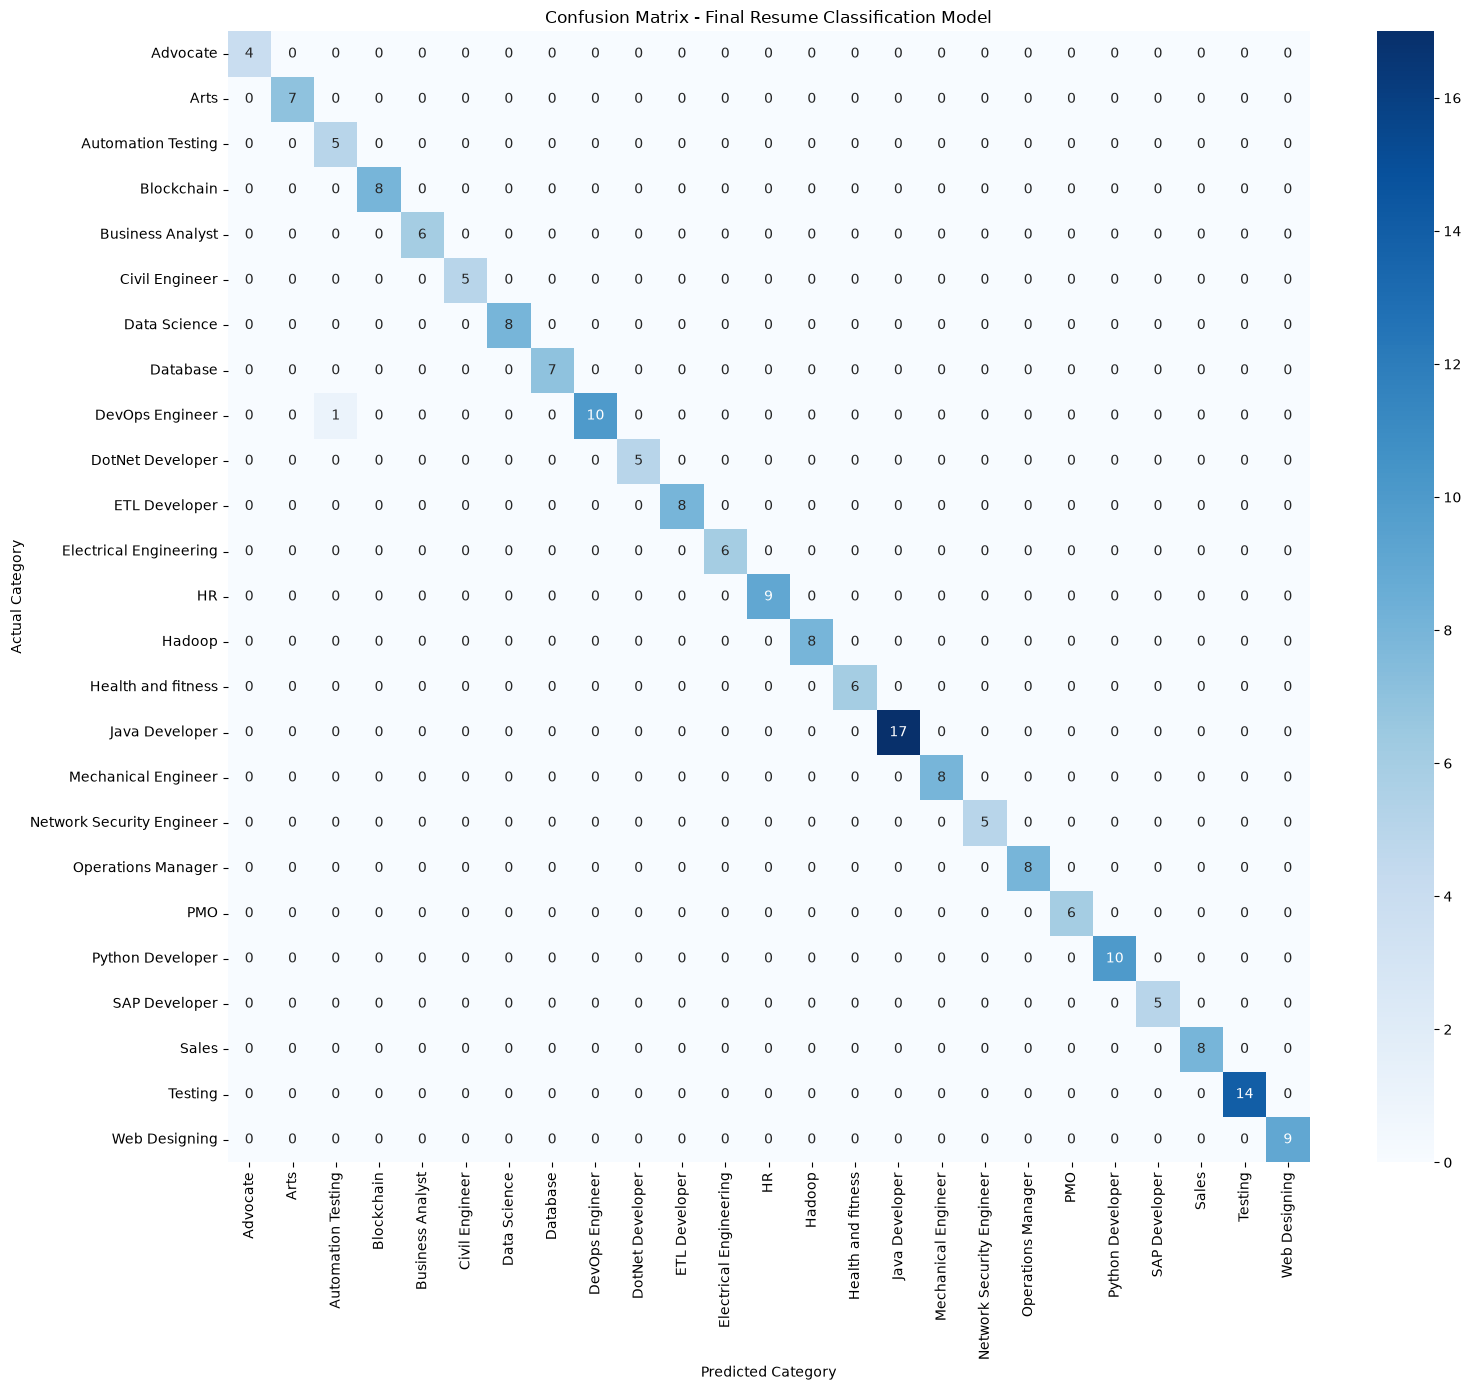

In [37]:
# ============================================================
# 26. CONFUSION MATRIX
# ============================================================

# Calculate the confusion matrix.
cm = confusion_matrix(
    y_test,
    final_predictions
)

# Create a large figure because there are many categories.
plt.figure(figsize=(16, 14))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Final Resume Classification Model")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
# ============================================================
# 27. CATEGORY-WISE PERFORMANCE
# ============================================================

# Generate per-category precision, recall and F1 scores.
category_report = classification_report(
    y_test,
    final_predictions,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

# Convert the report into a DataFrame.
category_performance = pd.DataFrame(
    category_report
).transpose()

# Remove aggregate rows so that only categories remain.
category_performance = category_performance.loc[
    label_encoder.classes_,
    ["precision", "recall", "f1-score", "support"]
]

display(category_performance)

,precision,recall,f1-score,support
Advocate,1.000000,1.000000,1.000000,4.0
Arts,1.000000,1.000000,1.000000,7.0
Automation Testing,0.833333,1.000000,0.909091,5.0
Blockchain,1.000000,1.000000,1.000000,8.0
Business Analyst,1.000000,1.000000,1.000000,6.0
Civil Engineer,1.000000,1.000000,1.000000,5.0
Data Science,1.000000,1.000000,1.000000,8.0
Database,1.000000,1.000000,1.000000,7.0
DevOps Engineer,1.000000,0.909091,0.952381,11.0
DotNet Developer,1.000000,1.000000,1.000000,5.0


In [39]:
# ============================================================
# 28. MISCLASSIFICATION ANALYSIS
# ============================================================

# Create a DataFrame containing test resumes and predictions.
error_analysis = pd.DataFrame({
    "Resume": X_test.values,
    "Actual Category": actual_categories,
    "Predicted Category": predicted_categories
})

# Keep only incorrectly classified resumes.
errors = error_analysis[
    error_analysis["Actual Category"] !=
    error_analysis["Predicted Category"]
].copy()

print(f"Incorrect predictions: {len(errors)}")
print(f"Total test samples  : {len(error_analysis)}")

# Display a sample of errors.
display(errors.head(10))

Incorrect predictions: 1
Total test samples  : 193


,Resume,Actual Category,Predicted Category
77,technical skills hp alm rtc and jira as400 iseries with sql test automation x framework in hours hsbc framework uft and lisa test data automation ...,DevOps Engineer,Automation Testing


In [40]:
# ============================================================
# 29. COMMON MISCLASSIFICATION PAIRS
# ============================================================

# Count combinations of actual and predicted categories.
confusion_pairs = (
    errors.groupby(
        ["Actual Category", "Predicted Category"]
    )
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

display(confusion_pairs.head(15))

,Actual Category,Predicted Category,Count
0,DevOps Engineer,Automation Testing,1


In [41]:
# ============================================================
# 30. IMPORTANT TF-IDF FEATURES
# ============================================================

# Get the vocabulary learned by TF-IDF.
feature_names = np.array(
    tfidf.get_feature_names_out()
)

# Linear SVM provides one coefficient vector per class.
coefficients = final_model.coef_

# Display important positive features for each category.
for class_index, category in enumerate(
    label_encoder.classes_
):

    # Sort coefficients from highest to lowest.
    top_indices = np.argsort(
        coefficients[class_index]
    )[-15:][::-1]

    top_features = feature_names[top_indices]

    print(f"\n{category}")
    print("-" * len(category))
    print(", ".join(top_features))


Advocate
--------
advocate, legal, law, llb, advocate skill, court, university advocate, criminal, details legal, llb law, courts, matters, llb dibrugarh, details llb, company legal

Arts
----
arts, karate, painting, championship, karate championship, total, drawing, fine arts, arts craft, craft teacher, ghatkopar ymca, drawing arts, ghatkopar, ymca, craft

Automation Testing
------------------
automation, automation testing, selenium, tester, manual, box, and automation, testing, manual and, box testing, black box, test, black, of test, automation tester

Blockchain
----------
blockchain, smart, ethereum, blockchain developer, solidity, smart contracts, contracts, january 2014, school blockchain, virtual, wallet, smart contract, blockchain engineer, nashik maharashtra, bitcoin

Business Analyst
----------------
business analyst, analyst, analyst business, report, business, cash, excel, in excel, mis in, functional, maintain daily, maintain, mass group, of companies, mms

Civil Engine

In [42]:
# ============================================================
# 31. RESUME PREDICTION FUNCTION
# ============================================================

def predict_resume(resume_text):
    """
    Predict the job category of a new resume.

    The function:
    1. Cleans the resume.
    2. Applies the previously fitted TF-IDF vectorizer.
    3. Uses the final trained classifier.
    4. Converts the numerical prediction back to a category.
    """

    # Clean the new resume using the same preprocessing
    # used during model training.
    cleaned_text = clean_resume_text(resume_text)

    # Transform the text using the already-fitted TF-IDF vectorizer.
    resume_features = tfidf.transform([cleaned_text])

    # Predict the numerical category.
    predicted_label = final_model.predict(
        resume_features
    )[0]

    # Convert the numerical label back to its category name.
    predicted_category = label_encoder.inverse_transform(
        [predicted_label]
    )[0]

    return predicted_category

In [43]:
# ============================================================
# 32. TEST THE PREDICTION FUNCTION
# ============================================================

sample_resume = """
Experienced data scientist with strong knowledge of Python,
machine learning, pandas, NumPy, scikit-learn, SQL and data analysis.
Experienced in building predictive models and working with datasets.
"""

prediction = predict_resume(sample_resume)

print("Predicted Resume Category:")
print(prediction)

Predicted Resume Category:
Data Science


In [44]:
# ============================================================
# 33. SAVE MODEL ARTIFACTS
# ============================================================

# Create a folder for trained model files.
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

# Save the TF-IDF vectorizer.
joblib.dump(
    tfidf,
    MODEL_DIR / "tfidf_vectorizer.pkl"
)

# Save the final classifier.
joblib.dump(
    final_model,
    MODEL_DIR / "resume_classifier.pkl"
)

# Save the label encoder.
joblib.dump(
    label_encoder,
    MODEL_DIR / "label_encoder.pkl"
)

print("All model artifacts saved successfully.")

All model artifacts saved successfully.


In [45]:
# ============================================================
# 34. RELOAD SAVED MODEL
# ============================================================

# Load the saved components.
loaded_tfidf = joblib.load(
    MODEL_DIR / "tfidf_vectorizer.pkl"
)

loaded_model = joblib.load(
    MODEL_DIR / "resume_classifier.pkl"
)

loaded_encoder = joblib.load(
    MODEL_DIR / "label_encoder.pkl"
)

# Transform the sample resume using the reloaded vectorizer.
sample_features = loaded_tfidf.transform(
    [clean_resume_text(sample_resume)]
)

# Predict using the reloaded classifier.
loaded_prediction = loaded_model.predict(
    sample_features
)[0]

# Convert the prediction to its category name.
loaded_category = loaded_encoder.inverse_transform(
    [loaded_prediction]
)[0]

print("Prediction after reloading model:")
print(loaded_category)

Prediction after reloading model:
Data Science


In [46]:
# ============================================================
# 35. FINAL RESULTS SUMMARY
# ============================================================

results_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ]
})

display(results_summary)

,Metric,Score
0,Accuracy,0.994819
1,Weighted Precision,0.995682
2,Weighted Recall,0.994819
3,Weighted F1,0.994931


In [47]:
# ============================================================
# 36. SAVE PROJECT RESULTS
# ============================================================

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# Save model comparison results.
comparison_df.to_csv(
    RESULTS_DIR / "model_comparison.csv",
    index=False
)

# Save cross-validation results.
cv_results_df.to_csv(
    RESULTS_DIR / "cross_validation_results.csv",
    index=False
)

# Save category-wise performance.
category_performance.to_csv(
    RESULTS_DIR / "category_performance.csv"
)

# Save misclassification analysis.
errors.to_csv(
    RESULTS_DIR / "misclassified_resumes.csv",
    index=False
)

# Save label mapping.
label_mapping.to_csv(
    RESULTS_DIR / "label_mapping.csv",
    index=False
)

print("All evaluation results saved successfully.")

All evaluation results saved successfully.


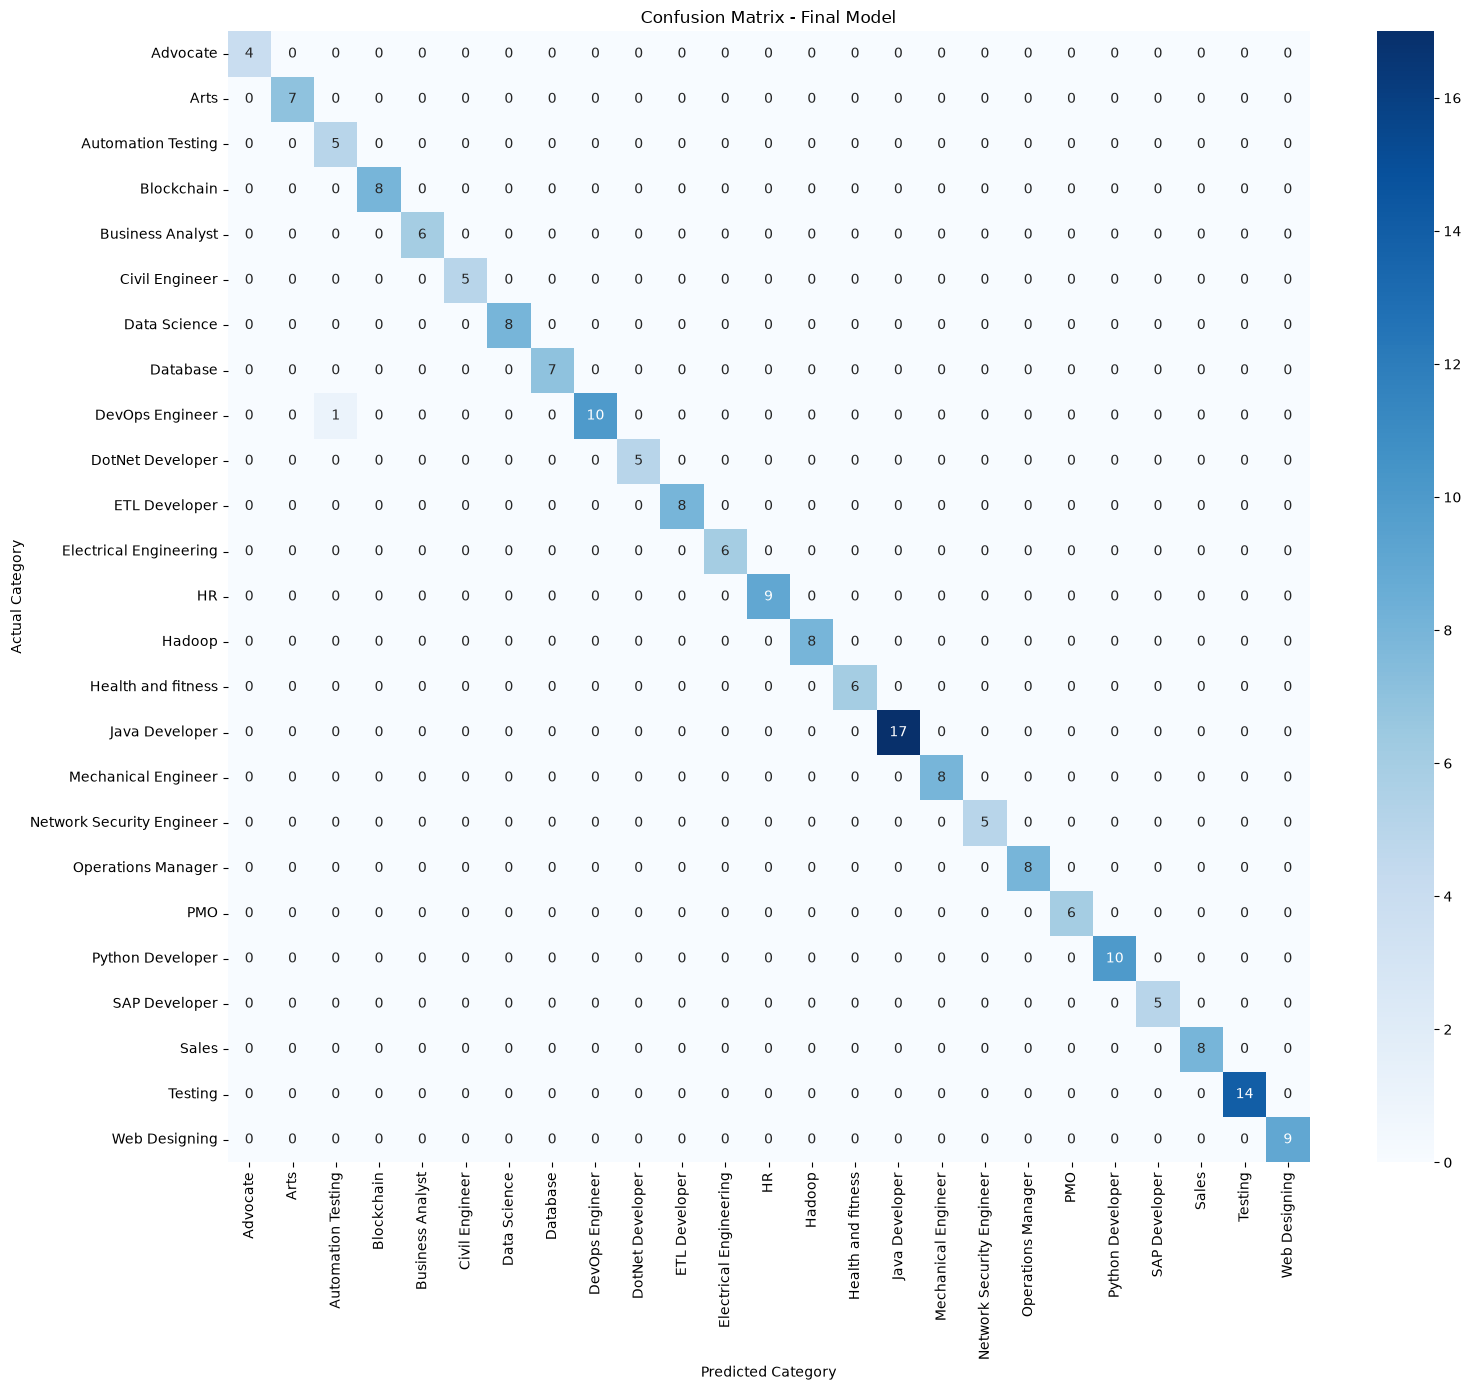

In [48]:
# ============================================================
# 37. SAVE CONFUSION MATRIX FIGURE
# ============================================================

plt.figure(figsize=(16, 14))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Final Model")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
# ============================================================
# 38. FINAL PROJECT SUMMARY
# ============================================================

print("=" * 70)
print("RESUME SCREENING ML PROJECT - FINAL SUMMARY")
print("=" * 70)

print(f"\nTotal original records       : {len(df)}")
print(f"Unique resumes used          : {len(model_df)}")
print(f"Number of categories         : {len(label_encoder.classes_)}")
print(f"Training samples             : {len(X_train)}")
print(f"Testing samples              : {len(X_test)}")

print("\nFINAL MODEL PERFORMANCE")
print("-" * 40)
print(f"Accuracy                    : {final_accuracy:.4f}")
print(f"Weighted Precision          : {final_precision:.4f}")
print(f"Weighted Recall             : {final_recall:.4f}")
print(f"Weighted F1 Score           : {final_f1:.4f}")

print("\nBEST HYPERPARAMETERS")
print("-" * 40)
print(grid_search.best_params_)

print("\nProject completed successfully.")

RESUME SCREENING ML PROJECT - FINAL SUMMARY

Total original records       : 962
Unique resumes used          : 962
Number of categories         : 25
Training samples             : 769
Testing samples              : 193

FINAL MODEL PERFORMANCE
----------------------------------------
Accuracy                    : 0.9948
Weighted Precision          : 0.9957
Weighted Recall             : 0.9948
Weighted F1 Score           : 0.9949

BEST HYPERPARAMETERS
----------------------------------------
{'C': 0.1, 'class_weight': 'balanced'}

Project completed successfully.


# 39. Limitations

Although the model provides useful resume-category classification, several limitations
should be considered.

1. The dataset contains a relatively small number of unique resume texts.
2. The original dataset contains many duplicate records.
3. Some professional categories have similar terminology.
4. Resume formatting and writing style can vary considerably.
5. The model is trained on the available dataset and may not generalize perfectly to
   resumes from different industries or geographical regions.
6. TF-IDF represents resumes using statistical word importance and does not fully
   understand semantic context.
7. The predicted category should be treated as an automated classification result,
   not as a complete recruitment decision.

# 40. Future Scope

The project can be extended in several ways:

- Use a larger dataset containing more unique resumes.
- Use transformer models such as BERT or DistilBERT.
- Extract individual skills from resumes.
- Extract education and experience information.
- Extract years of experience.
- Match resumes against specific job descriptions.
- Build resume-to-job similarity scoring.
- Add explainable AI techniques.
- Support multiple languages.
- Deploy the application to a cloud platform.
- Add an interactive recruiter dashboard.